# 🛒 Customer Retail Dataset — ML Model Comparison
### DevTown 5-Day Machine Learning Mastery Bootcamp
**Models Used:** Logistic Regression | Decision Tree | K-Nearest Neighbors  
**Dataset:** UCI Online Retail Dataset  
**Goal:** Classify transactions as High-Value or Low-Value and compare model performances


## 📦 Step 1 — Install & Import Libraries

In [1]:
# All libraries come pre-installed in Google Colab — no pip install needed!

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 📥 Step 2 — Load the Dataset

**Option A (Recommended):** Download directly from Kaggle using the code below.  
**Option B:** Upload the file manually using the Colab file upload button.

Dataset link: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci


In [2]:
# ── OPTION A: Download from URL (no Kaggle account needed) ────────────────────
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
print("Downloading dataset... please wait ⏳")

try:
    urllib.request.urlretrieve(url, "online_retail.xlsx")
    df = pd.read_excel("online_retail.xlsx")
    print(f"✅ Dataset downloaded! Shape: {df.shape}")
except Exception as e:
    print(f"❌ Download failed: {e}")
    print("👉 Use Option B: Upload manually below")

# ── OPTION B: Upload manually (uncomment if Option A fails) ───────────────────
# from google.colab import files
# uploaded = files.upload()   # click 'Choose File' and upload online_retail.xlsx or .csv
# import io
# df = pd.read_excel(io.BytesIO(list(uploaded.values())[0]))
# print(f"✅ File uploaded! Shape: {df.shape}")


✅ Dataset downloaded! Shape: (541909, 8)


## 🔍 Step 3 — Explore the Dataset

In [3]:
print("── Shape ──────────────────────────────")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

print("\n── First 5 Rows ────────────────────────")
display(df.head())

print("\n── Column Info ─────────────────────────")
print(df.dtypes)

print("\n── Missing Values ──────────────────────")
print(df.isnull().sum())


── Shape ──────────────────────────────
Rows: 541,909  |  Columns: 8

── First 5 Rows ────────────────────────


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



── Column Info ─────────────────────────
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

── Missing Values ──────────────────────
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


## 🧹 Step 4 — Data Cleaning & Preprocessing

In [4]:
# ── 4a. Keep only required columns ───────────────────────────────────────────
df = df[['Quantity', 'UnitPrice', 'Country']].copy()

# ── 4b. Drop missing values ───────────────────────────────────────────────────
df.dropna(inplace=True)

# ── 4c. Remove invalid rows (negative qty or price = returns/errors) ──────────
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# ── 4d. Encode Country column (text → number) ─────────────────────────────────
le = LabelEncoder()
df['Country_Encoded'] = le.fit_transform(df['Country'])

# ── 4e. Feature Engineering: create target variable ──────────────────────────
#   TotalAmount = how much money was spent in this transaction
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

#   HighValue = 1 if TotalAmount is above median, else 0
median_val = df['TotalAmount'].median()
df['HighValue'] = (df['TotalAmount'] > median_val).astype(int)

print(f"✅ Preprocessing done!")
print(f"   Clean dataset shape : {df.shape}")
print(f"   Median TotalAmount  : £{median_val:.2f}")
print(f"\n── Target Class Distribution ──────────")
print(df['HighValue'].value_counts())
print(f"\n── Class Balance ───────────────────────")
print((df['HighValue'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')


✅ Preprocessing done!
   Clean dataset shape : (530104, 6)
   Median TotalAmount  : £9.90

── Target Class Distribution ──────────
HighValue
0    266446
1    263658
Name: count, dtype: int64

── Class Balance ───────────────────────
HighValue
0    50.26%
1    49.74%
Name: proportion, dtype: object


## 📊 Step 5 — Data Visualisation

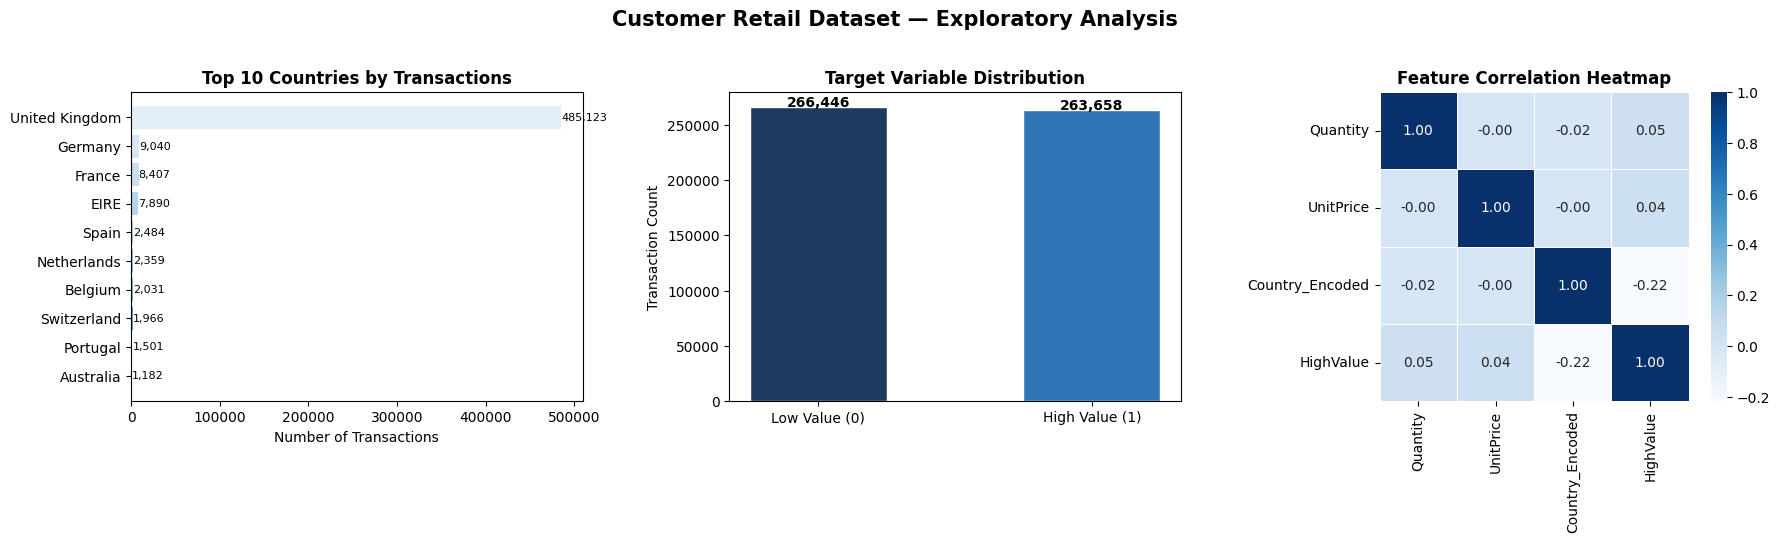

✅ Visualisations saved as 'customer_distribution.png'


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Customer Retail Dataset — Exploratory Analysis',
             fontsize=15, fontweight='bold', y=1.02)

# ── Graph 1: Top 10 Countries by Transaction Count ────────────────────────────
top_countries = df['Country'].value_counts().head(10)
axes[0].barh(top_countries.index[::-1], top_countries.values[::-1],
             color=plt.cm.Blues_r(np.linspace(0.3, 0.9, 10)))
axes[0].set_title('Top 10 Countries by Transactions', fontweight='bold')
axes[0].set_xlabel('Number of Transactions')
for i, v in enumerate(top_countries.values[::-1]):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=8)

# ── Graph 2: Target Class Distribution ───────────────────────────────────────
counts = df['HighValue'].value_counts()
bars = axes[1].bar(['Low Value (0)', 'High Value (1)'], counts.values,
                   color=['#1E3A5F', '#2E75B6'], edgecolor='white', width=0.5)
axes[1].set_title('Target Variable Distribution', fontweight='bold')
axes[1].set_ylabel('Transaction Count')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{bar.get_height():,}', ha='center', fontweight='bold')

# ── Graph 3: Correlation Heatmap ──────────────────────────────────────────────
corr_cols = ['Quantity', 'UnitPrice', 'Country_Encoded', 'HighValue']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=axes[2], square=True)
axes[2].set_title('Feature Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.savefig('customer_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisations saved as 'customer_distribution.png'")


## ✂️ Step 6 — Prepare Features & Split Data

In [6]:
# Features (X) and Target (y)
X = df[['Quantity', 'UnitPrice', 'Country_Encoded']]
y = df['HighValue']

# 80% train, 20% test — stratify keeps class balance in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"✅ Data split complete!")
print(f"   Total samples  : {len(X):,}")
print(f"   Training set   : {len(X_train):,} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"   Testing set    : {len(X_test):,}  rows ({len(X_test)/len(X)*100:.0f}%)")


✅ Data split complete!
   Total samples  : 530,104
   Training set   : 424,083 rows (80%)
   Testing set    : 106,021  rows (20%)


## 🤖 Step 7 — Train All Three Models

In [7]:
# ── Model 1: Logistic Regression ─────────────────────────────────────────────
print("Training Model 1: Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print("   ✅ Done!")

# ── Model 2: Decision Tree Classifier ────────────────────────────────────────
print("Training Model 2: Decision Tree...")
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
print("   ✅ Done!")

# ── Model 3: K-Nearest Neighbors (KNN) ───────────────────────────────────────
print("Training Model 3: KNN (k=7)...")
knn_model = KNeighborsClassifier(n_neighbors=7, metric='euclidean')
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
print("   ✅ Done!")

print("\n🎉 All 3 models trained successfully!")


Training Model 1: Logistic Regression...
   ✅ Done!
Training Model 2: Decision Tree...
   ✅ Done!
Training Model 3: KNN (k=7)...
   ✅ Done!

🎉 All 3 models trained successfully!


## 📈 Step 8 — Evaluate Models

In [8]:
# ── Accuracy Scores ───────────────────────────────────────────────────────────
lr_acc  = accuracy_score(y_test, lr_pred)
dt_acc  = accuracy_score(y_test, dt_pred)
knn_acc = accuracy_score(y_test, knn_pred)

print("=" * 52)
print("       MODEL ACCURACY RESULTS")
print("=" * 52)
print(f"  Logistic Regression  :  {lr_acc:.4f}  ({lr_acc*100:.2f}%)")
print(f"  Decision Tree (d=5)  :  {dt_acc:.4f}  ({dt_acc*100:.2f}%)")
print(f"  KNN (k=7)            :  {knn_acc:.4f}  ({knn_acc*100:.2f}%)")
print("=" * 52)

best = max([("Logistic Regression", lr_acc),
            ("Decision Tree", dt_acc),
            ("KNN", knn_acc)], key=lambda x: x[1])
print(f"\n🏆 Best Model: {best[0]} with {best[1]*100:.2f}% accuracy")


       MODEL ACCURACY RESULTS
  Logistic Regression  :  0.8502  (85.02%)
  Decision Tree (d=5)  :  0.9743  (97.43%)
  KNN (k=7)            :  0.9991  (99.91%)

🏆 Best Model: KNN with 99.91% accuracy


## 🔲 Step 9 — Confusion Matrices

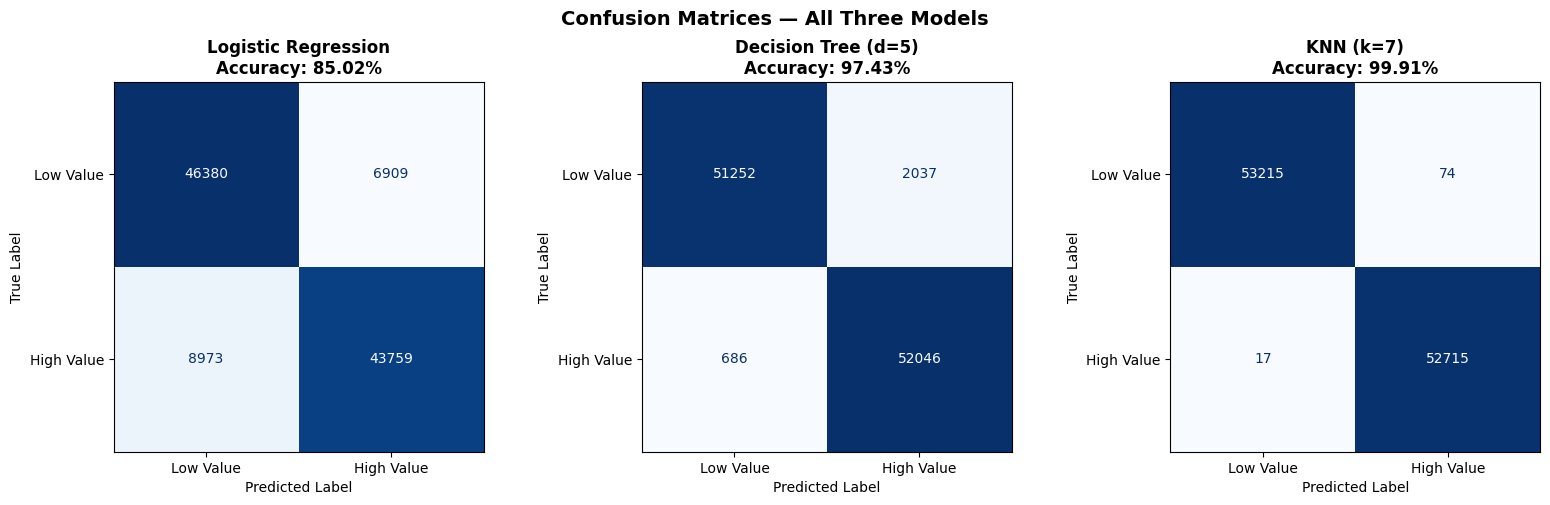

✅ Confusion matrices saved as 'confusion_matrices.png'


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices — All Three Models',
             fontsize=14, fontweight='bold')

models_info = [
    ("Logistic Regression", lr_pred, lr_acc),
    ("Decision Tree (d=5)", dt_pred, dt_acc),
    ("KNN (k=7)",           knn_pred, knn_acc),
]

for ax, (name, pred, acc) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Low Value', 'High Value'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nAccuracy: {acc:.2%}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved as 'confusion_matrices.png'")


## 📊 Step 10 — Model Accuracy Comparison Graph

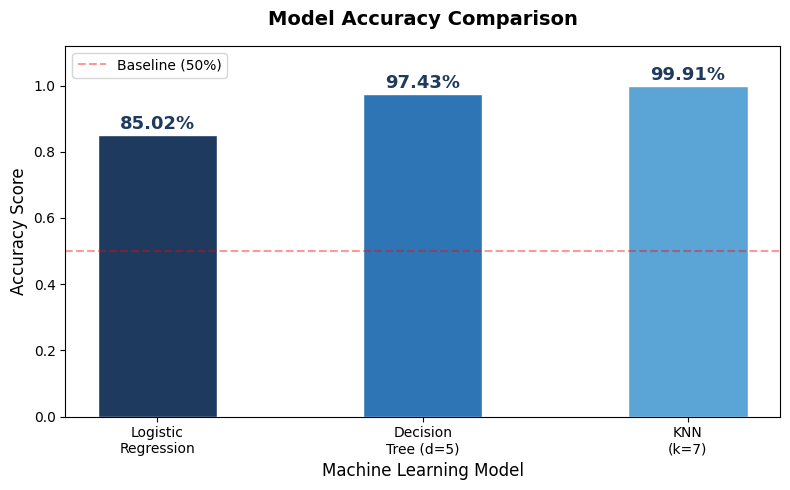

✅ Accuracy comparison graph saved as 'model_accuracy_comparison.png'


In [10]:
model_names = ['Logistic\nRegression', 'Decision\nTree (d=5)', 'KNN\n(k=7)']
accuracies  = [lr_acc, dt_acc, knn_acc]
colors      = ['#1E3A5F', '#2E75B6', '#5BA4D6']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=colors,
               edgecolor='white', width=0.45)

# Add % labels on top of bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f'{acc:.2%}',
             ha='center', va='bottom',
             fontsize=13, fontweight='bold', color='#1E3A5F')

plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Machine Learning Model', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0, 1.12)
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.4, label='Baseline (50%)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('model_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Accuracy comparison graph saved as 'model_accuracy_comparison.png'")


## 📋 Step 11 — Detailed Classification Reports

In [11]:
for name, pred in [("Logistic Regression", lr_pred),
                   ("Decision Tree (d=5)", dt_pred),
                   ("KNN (k=7)",           knn_pred)]:
    print(f"\n{'='*50}")
    print(f"  {name}")
    print('='*50)
    print(classification_report(y_test, pred,
          target_names=['Low Value', 'High Value']))



  Logistic Regression
              precision    recall  f1-score   support

   Low Value       0.84      0.87      0.85     53289
  High Value       0.86      0.83      0.85     52732

    accuracy                           0.85    106021
   macro avg       0.85      0.85      0.85    106021
weighted avg       0.85      0.85      0.85    106021


  Decision Tree (d=5)
              precision    recall  f1-score   support

   Low Value       0.99      0.96      0.97     53289
  High Value       0.96      0.99      0.97     52732

    accuracy                           0.97    106021
   macro avg       0.97      0.97      0.97    106021
weighted avg       0.97      0.97      0.97    106021


  KNN (k=7)
              precision    recall  f1-score   support

   Low Value       1.00      1.00      1.00     53289
  High Value       1.00      1.00      1.00     52732

    accuracy                           1.00    106021
   macro avg       1.00      1.00      1.00    106021
weighted avg   

## 🏁 Step 12 — Final Summary

In [12]:
summary = pd.DataFrame({
    'Model'   : ['Logistic Regression', 'Decision Tree (d=5)', 'KNN (k=7)'],
    'Accuracy': [f'{lr_acc:.4f}', f'{dt_acc:.4f}', f'{knn_acc:.4f}'],
    'Accuracy %': [f'{lr_acc*100:.2f}%', f'{dt_acc*100:.2f}%', f'{knn_acc*100:.2f}%'],
    'Best Model?': [
        '🏆' if lr_acc  == max(lr_acc, dt_acc, knn_acc) else '',
        '🏆' if dt_acc  == max(lr_acc, dt_acc, knn_acc) else '',
        '🏆' if knn_acc == max(lr_acc, dt_acc, knn_acc) else '',
    ]
})

print("\n" + "="*55)
print("   FINAL MODEL COMPARISON — DevTown ML Bootcamp Project")
print("="*55)
display(summary)
print("\n✅ Project Complete! All outputs saved:")
print("   📊 customer_distribution.png")
print("   🔲 confusion_matrices.png")
print("   📈 model_accuracy_comparison.png")



   FINAL MODEL COMPARISON — DevTown ML Bootcamp Project


,Model,Accuracy,Accuracy %,Best Model?
0,Logistic Regression,0.8502,85.02%,
1,Decision Tree (d=5),0.9743,97.43%,
2,KNN (k=7),0.9991,99.91%,🏆



✅ Project Complete! All outputs saved:
   📊 customer_distribution.png
   🔲 confusion_matrices.png
   📈 model_accuracy_comparison.png
